In [13]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

colors = ["#3498DB", "#E74C3C"]

df = pd.read_csv(r"C:\Users\HP\Downloads\healthcare-dataset-stroke-data.csv")

In [14]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [15]:
df.drop(columns=["id"], inplace=True)

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df["stroke"].value_counts())
print(f"\nStroke Rate: {df['stroke'].mean()*100:.2f}%")

Dataset Shape: (5110, 11)

Class Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke Rate: 4.87%


In [16]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [17]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 439.3 KB


In [ ]:
# Observations:

#5,110 patients, 10 features (after dropping id)
#bmi has 201 missing values — imputed with train-set median to avoid data leakage
#Mix of numerical (age, bmi, avg_glucose_level) and categorical features
#Target: stroke (binary: 0 = no stroke, 1 = stroke)
/*

C:\Users\HP\AppData\Local\Temp\ipykernel_3360\4132726794.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, palette="Reds_r")


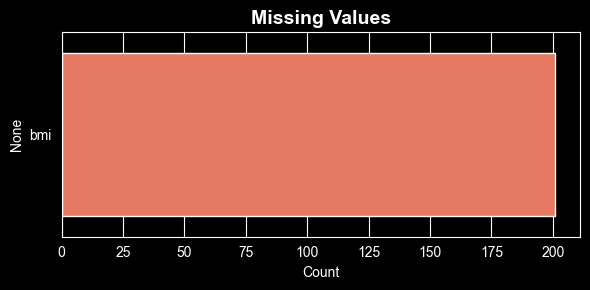

In [20]:
##2 Exploratory Data Anaylysis

missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(6,3))
sns.barplot(x=missing.values, y=missing.index, palette="Reds_r")
plt.title("Missing Values", fontsize=14, fontweight="bold")
plt.xlabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
#Only bmi has missing values (~3.9%). We fill with the training set median after splitting to prevent leakage.

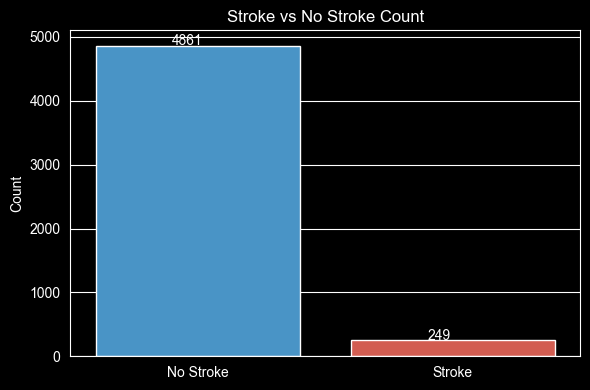

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [21]:
#2.2 Class Imbalance¶

plt.figure(figsize=(6, 4))
ax = sns.countplot(x="stroke", data=df, hue="stroke", palette=colors, legend=False)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + 0.3, p.get_height() + 10))
plt.title("Stroke vs No Stroke Count")
plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.xlabel("")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
print(df["stroke"].value_counts(normalize=True) * 100)

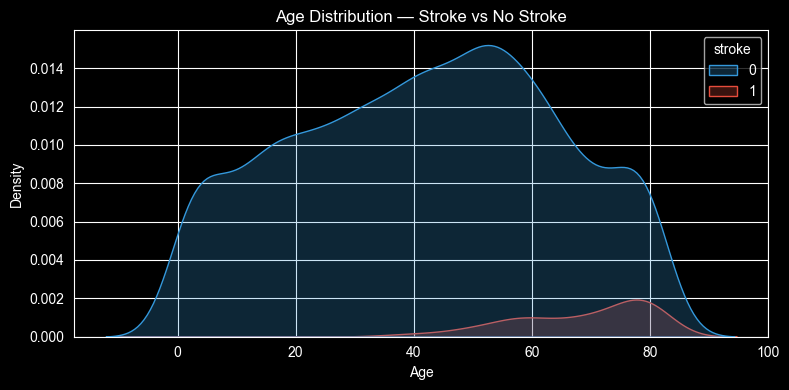

In [22]:
# Age Distribution — Key Risk Factor¶
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="age", hue="stroke", fill=True, palette=colors)
plt.title("Age Distribution — Stroke vs No Stroke")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

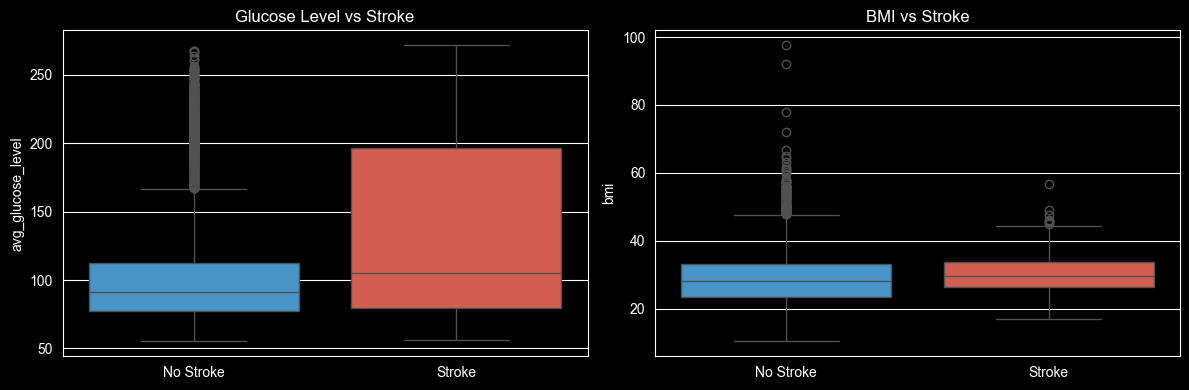

In [23]:
#Glucose Level & BMI vs Stroke
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="stroke", y="avg_glucose_level", hue="stroke",
            data=df, palette=colors, legend=False, ax=axes[0])
axes[0].set_title("Glucose Level vs Stroke")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No Stroke", "Stroke"])
axes[0].set_xlabel("")
sns.boxplot(x="stroke", y="bmi", hue="stroke",
            data=df, palette=colors, legend=False, ax=axes[1])
axes[1].set_title("BMI vs Stroke")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No Stroke", "Stroke"])
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_3360\2476606366.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No", "Yes"])
C:\Users\HP\AppData\Local\Temp\ipykernel_3360\2476606366.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No", "Yes"])


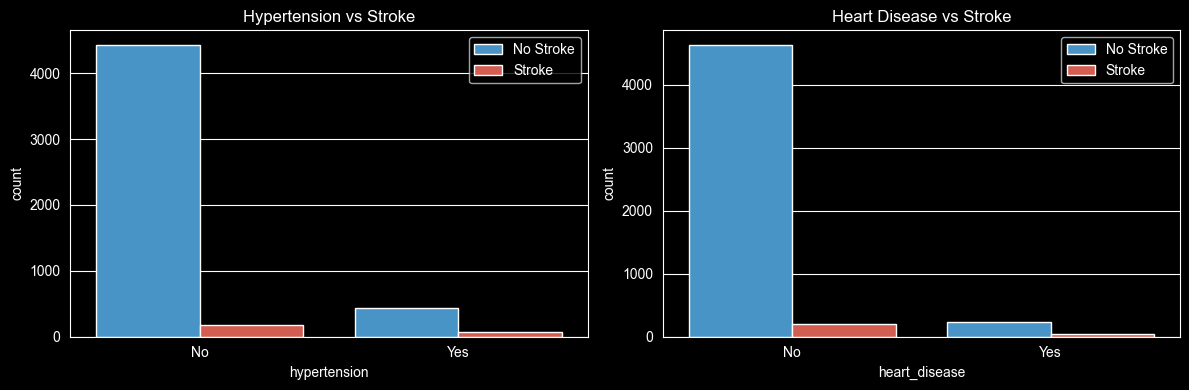

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="hypertension", hue="stroke", data=df, palette=colors, ax=axes[0])
axes[0].set_title("Hypertension vs Stroke")
axes[0].set_xticklabels(["No", "Yes"])
axes[0].legend(["No Stroke", "Stroke"])
sns.countplot(x="heart_disease", hue="stroke", data=df, palette=colors, ax=axes[1])
axes[1].set_title("Heart Disease vs Stroke")
axes[1].set_xticklabels(["No", "Yes"])
axes[1].legend(["No Stroke", "Stroke"])
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_3360\1688273268.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y="stroke", data=stroke_rate, palette="Reds", ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_3360\1688273268.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y="stroke", data=stroke_rate, palette="Reds", ax=axes[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_3360\1688273268.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y="stroke", data=stroke_rate, palette="Reds", ax=axes[i])
C:\Users\HP\AppData\Local

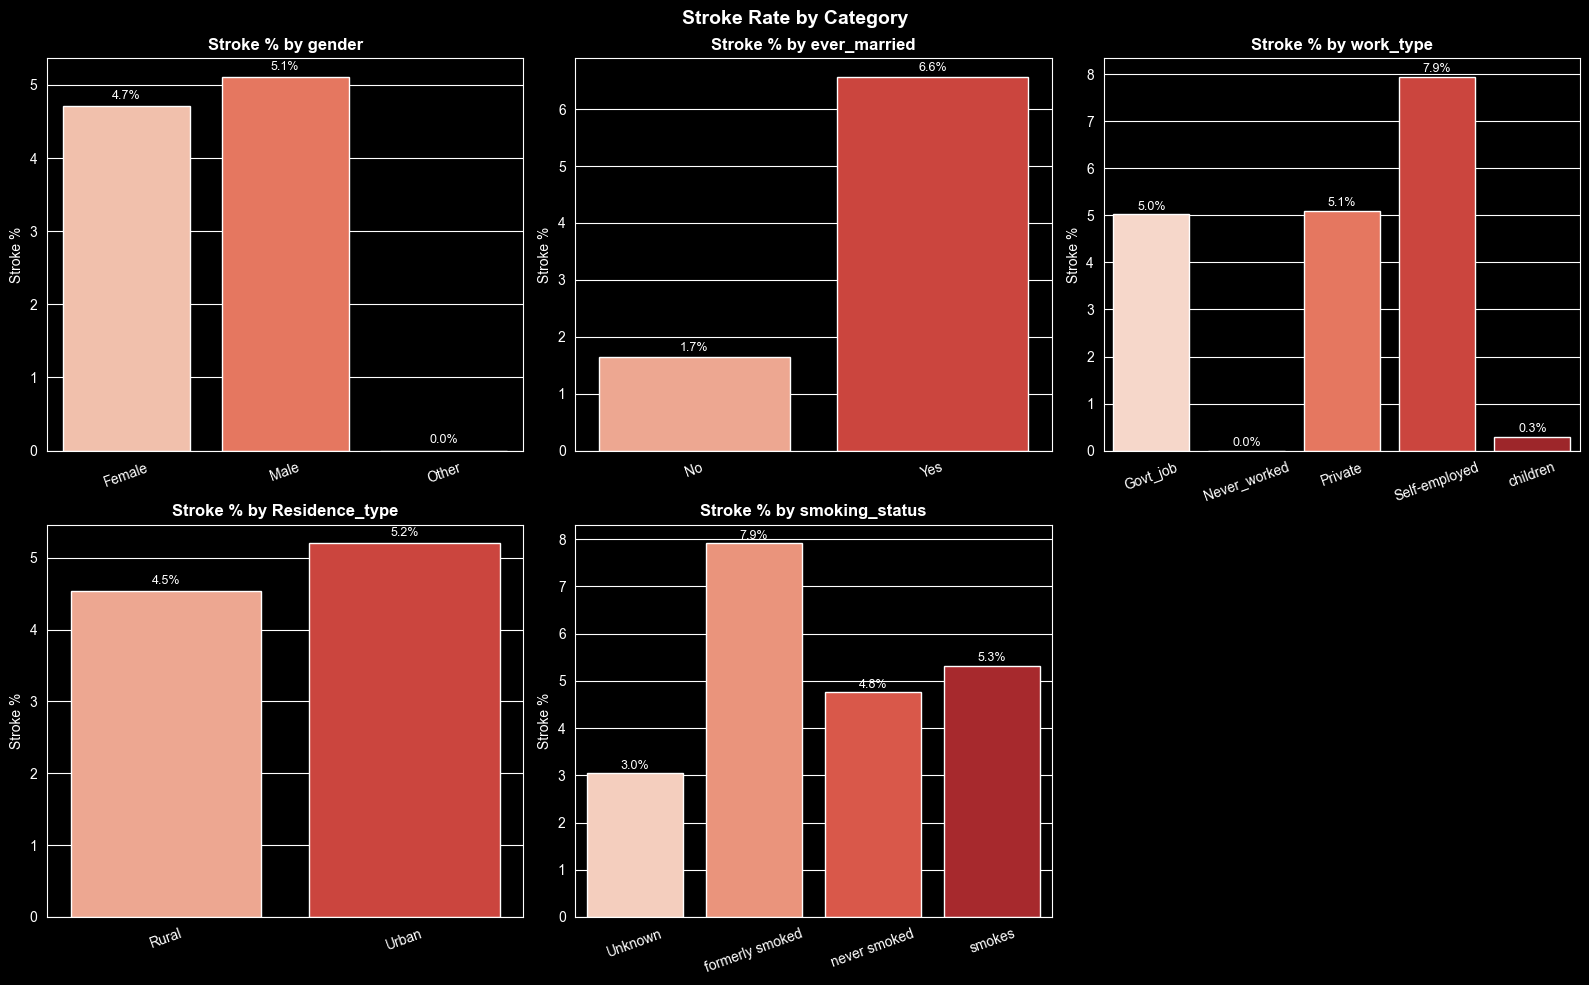

In [25]:
# Stroke Rate by Categorical Features

cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    stroke_rate = df.groupby(col)["stroke"].mean().reset_index()
    stroke_rate["stroke"] = stroke_rate["stroke"] * 100
    sns.barplot(x=col, y="stroke", data=stroke_rate, palette="Reds", ax=axes[i])
    for p in axes[i].patches:
        axes[i].annotate(
            f'{p.get_height():.1f}%',
            (p.get_x() + p.get_width() / 2, p.get_height() + 0.1),
            ha="center", fontsize=9
        )
    axes[i].set_title(f"Stroke % by {col}", fontweight="bold")
    axes[i].set_ylabel("Stroke %")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=20)
axes[-1].set_visible(False)
plt.suptitle("Stroke Rate by Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

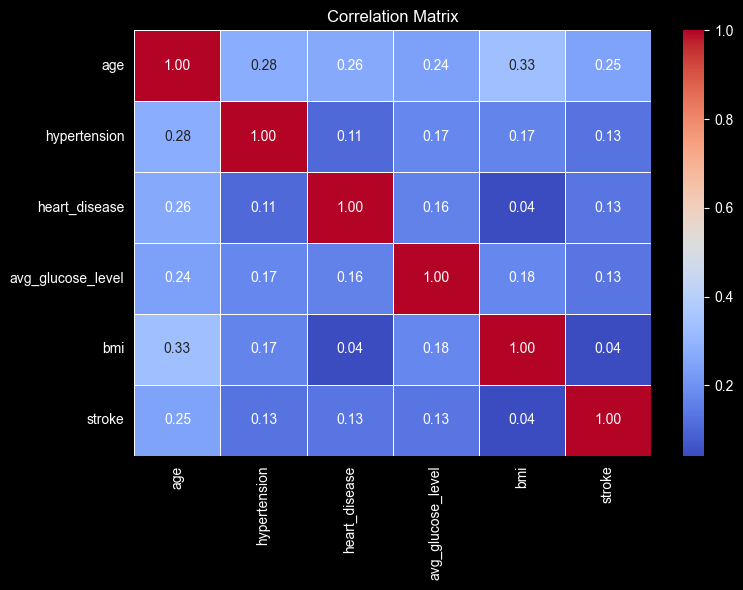

In [26]:
# Correlation Heatmap¶

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True,
            fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.model_selection import train_test_split

# remove extra spaces from column names
df.columns = df.columns.str.strip()

X = df.drop("stroke", axis=1)
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (4088, 10)
Test: (1022, 10)


In [30]:
bmi_median_train = X_train["bmi"].median()
X_train["bmi"] = X_train["bmi"].fillna(bmi_median_train)
X_test["bmi"]  = X_test["bmi"].fillna(bmi_median_train)
print(f"BMI median (train): {bmi_median_train:.2f}")
print(f"Nulls remaining: {X_train['bmi'].isnull().sum()}")

BMI median (train): 28.00
Nulls remaining: 0


In [31]:
#3.3 New Interaction Features¶

for dataset in [X_train, X_test]:
    dataset["age_group"] = pd.cut(
        dataset["age"], bins=[0, 30, 60, 100], labels=[0, 1, 2]
    ).astype(int)
    dataset["age_hypertension"] = dataset["age"] * dataset["hypertension"]
    dataset["glucose_bmi"]      = dataset["avg_glucose_level"] * dataset["bmi"]

print("New features added: age_group, age_hypertension, glucose_bmi")
print("Train shape:", X_train.shape)

New features added: age_group, age_hypertension, glucose_bmi
Train shape: (4088, 13)


In [32]:
#3.4 One-Hot Encoding¶

X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

bool_cols = X_train.select_dtypes("bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)

print("Final shape:", X_train.shape)
print(X_train.dtypes)

Final shape: (4088, 19)
age                               float64
hypertension                        int64
heart_disease                       int64
avg_glucose_level                 float64
bmi                               float64
age_group                           int64
age_hypertension                  float64
glucose_bmi                       float64
gender_Male                         int64
gender_Other                        int64
ever_married_Yes                    int64
work_type_Never_worked              int64
work_type_Private                   int64
work_type_Self-employed             int64
work_type_children                  int64
Residence_type_Urban                int64
smoking_status_formerly smoked      int64
smoking_status_never smoked         int64
smoking_status_smokes               int64
dtype: object


In [38]:
##4.  Class Imbalance — SMOTE¶
#A naive model would predict "No Stroke" for everyone and get 95% accuracy — completely useless.
#SMOTE generates synthetic minority samples by interpolating between existing stroke cases.
#Applied only on training data to prevent test set contamination.


from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(y_train.value_counts()))
print("After SMOTE: ", dict(y_train_res.value_counts()))


Before SMOTE: {0: np.int64(3889), 1: np.int64(199)}
After SMOTE:  {0: np.int64(3889), 1: np.int64(3889)}


In [37]:
!pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
pip list


Package                 Version
----------------------- -----------
asttokens               3.0.1
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.3.1
executing               2.2.1
fonttools               4.63.0
ipykernel               7.2.0
ipython                 9.13.0
ipython_pygments_lexers 1.1.1
jedi                    0.20.0
joblib                  1.5.3
jupyter_client          8.8.0
jupyter_core            5.9.1
kiwisolver              1.5.0
matplotlib              3.10.9
matplotlib-inline       0.2.2
nest-asyncio            1.6.0
numpy                   2.4.6
packaging               26.2
pandas                  3.0.3
parso                   0.8.7
pillow                  12.2.0
pip                     25.1.1
platformdirs            4.9.6
prompt_toolkit          3.0.52
psutil                  7.2.2
pure_eval               0.2.3
Pygments                

In [39]:
##5 Model training
#We train 3 models in increasing complexity:

#Logistic Regression — Simple linear baseline
#Random Forest — Ensemble with balanced class weights
#XGBoost + Optuna — Gradient boosting with automated hyperparameter search
#Primary metric: Recall on stroke class (minimize missed strokes)

#5.1 Logistic Regression (Baseline)¶

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_scaled, y_train_res)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]

print("=" * 40)
print("LOGISTIC REGRESSION")
print("=" * 40)
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       972
           1       0.19      0.50      0.28        50

    accuracy                           0.87      1022
   macro avg       0.58      0.70      0.60      1022
weighted avg       0.93      0.87      0.90      1022

ROC-AUC: 0.7759


In [40]:
#5.2 Random Forest¶
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight="balanced"
)
rf.fit(X_train_res, y_train_res)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf > 0.3).astype(int)  # Lower threshold to boost recall

print("=" * 40)
print("RANDOM FOREST")
print("=" * 40)
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       972
           1       0.11      0.26      0.15        50

    accuracy                           0.86      1022
   macro avg       0.53      0.58      0.54      1022
weighted avg       0.92      0.86      0.89      1022

ROC-AUC: 0.7568


In [45]:
#5.3 XGBoost + Optuna Tuning¶
#Optuna runs 50 trials, each testing different XGBoost hyperparameters, and maximizes Recall on the stroke class automatically.

import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 400),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2),
        "scale_pos_weight": trial.suggest_int("scale_pos_weight", 4, 6),
        "random_state":     42,
        "eval_metric":      "logloss"
    }
    model = XGBClassifier(**params)
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    return recall_score(y_test, y_pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
print("Best params:", study.best_params)

Best params: {'n_estimators': 135, 'max_depth': 4, 'learning_rate': 0.010157461338867985, 'scale_pos_weight': 6}


In [44]:
!pip install xgboost optuna

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.5 MB/s eta 0:01:09
   ---------------------------------------- 0.8/101.7 MB 1.6 MB/s eta 0:01:05
   ---------------------------------------- 1.0/101.7 MB 1.1 MB/s eta 0:01:32
    --------------------------------------- 1.6/101.7 MB 1.4 MB/s eta 0:01:11
    --------------------------------------- 2.1/101.7 MB 1.6 MB/s eta 0:01:01
   - -------------------------------------- 2.9/101.7 MB 1.9 MB/s eta 0:00:51
   - -------------------------------------- 3.4/101.7 MB 2.1 MB/s eta 0:00:48
   - -------------------------------------- 3.9/101.7 MB 2.1 MB/s eta 0:00:47
   - -------------------------------------- 5.0/101.7 MB 2.4 MB/s eta 0:00:41
   -- ------------------------------------- 5.8/101.7 MB 2.6 MB/s eta 0:00:38
   -- -


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
best_model = XGBClassifier(**study.best_params, eval_metric="logloss")
best_model.fit(X_train_res, y_train_res)

y_prob_xgb = best_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb > 0.5).astype(int)

print("=" * 40)
print("XGBOOST (TUNED)")
print("=" * 40)
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

XGBOOST (TUNED)
              precision    recall  f1-score   support

           0       0.99      0.59      0.74       972
           1       0.10      0.84      0.17        50

    accuracy                           0.60      1022
   macro avg       0.54      0.72      0.46      1022
weighted avg       0.94      0.60      0.71      1022

ROC-AUC: 0.7651


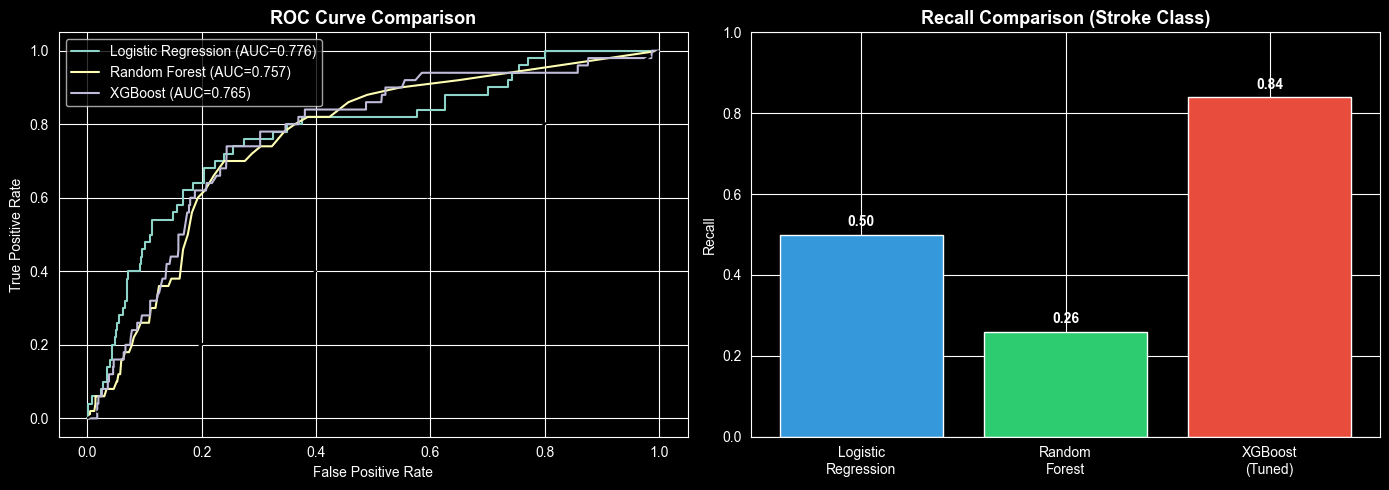

In [47]:
##6. Model Comparison — ROC & Recall

from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, y_prob in [("Logistic Regression", y_prob_lr),
                      ("Random Forest",       y_prob_rf),
                      ("XGBoost",             y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

axes[0].plot([0,1],[0,1],"k--")
axes[0].set_title("ROC Curve Comparison", fontsize=13, fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

models  = ["Logistic\nRegression", "Random\nForest", "XGBoost\n(Tuned)"]
recalls = [
    recall_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_xgb)
]
bars = axes[1].bar(models, recalls, color=["#3498DB", "#2ECC71", "#E74C3C"])
axes[1].set_title("Recall Comparison (Stroke Class)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, recalls):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02, f"{val:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
##7 Model Explainability — SHAP Values
#SHAP (SHapley Additive exPlanations) tells us why the model made each prediction.

#Features pushing right increase stroke probability
#Red dots = high feature value, Blue dots = low feature value

   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 559.2/559.2 kB 3.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   - -------------------------------------- 1.3/39.2 MB 7.1 MB/s eta 0:00:06
   -- ------------------------------------- 2.4/39.2 MB 6.7 MB/s eta 0:00:06
   --- ------------------------------------ 3.1/39.2 MB 5.3 MB/s eta 0:00:07
   ---- ----------------------------------- 4.5/39.2 MB 5.7 MB/s eta 0:00:07
   ------ --------------------------------- 6.0/39.2 MB 6.0 MB/s eta 0:00:06
   ------- -------------------------------- 7.1/39.2 MB 6.0 MB/s eta 0:00:06
   ------- -------------------------------- 7.6/39.2 MB 5.3 MB/s eta 0:00:06
   --------- ------------------------------ 8.9/39.2 MB 5.5 MB/s eta 0:00:06
   ---------- ----------------------------- 10.2/39.2 MB 5.6 MB/s eta 0:00:06
   ----------- ---------------------------- 11.3/39.2 MB 5.6 MB/s eta 0:00:06
   ----


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


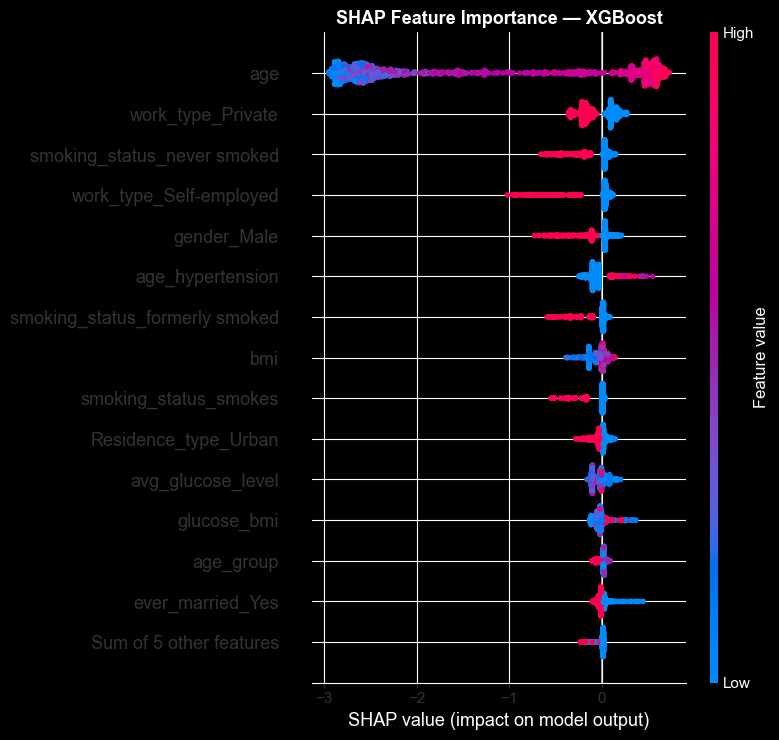

In [49]:
!pip install shap
import shap

explainer   = shap.Explainer(best_model)
shap_values = explainer(X_test)

plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Feature Importance — XGBoost", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [50]:
##8. Save Model Artifacts¶

import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(best_model,               "models/stroke_model.pkl")
joblib.dump(X_train.columns.tolist(), "models/feature_columns.pkl")
joblib.dump(0.61,                     "models/threshold.pkl")
joblib.dump(bmi_median_train,         "models/bmi_median.pkl")

print("Saved artifacts:")
for f in ["stroke_model.pkl", "feature_columns.pkl", "threshold.pkl", "bmi_median.pkl"]:
    print(f"  ✅ {f}")

Saved artifacts:
  ✅ stroke_model.pkl
  ✅ feature_columns.pkl
  ✅ threshold.pkl
  ✅ bmi_median.pkl


In [ ]:
##Conclusion & Key Takeaways¶
#What We Built
#A complete end-to-end stroke prediction pipeline: EDA → Feature Engineering → SMOTE → Model Comparison → Optuna Tuning → SHAP Explainability → Deployment-ready artifacts.